In [39]:
import sys

sys.path.append("..")


from mri_loader import MRI, Subject

import pandas as pd
import numpy as np



In [40]:
subject_id = 7

run_ids = list(range(1, 5))

(subject_id, run_ids)

(7, [1, 2, 3, 4])

In [41]:
dataset = [MRI(subject_id, run_id, folder="..", confound_mode="reduced") for run_id in run_ids]

[mri.load() for mri in dataset]

s = Subject(subject_id, run_ids, folder="..", confound_mode="reduced")

dataset

In [42]:
dataset[0].labels["run time"].values /1000

array([  0.849,   6.752,  11.654,  15.055,  19.44 ,  24.626,  29.027,
        34.429,  40.115,  44.517,  49.619,  54.121,  58.323,  62.924,
        67.326,  73.129,  78.531,  88.318,  92.32 ,  97.122, 102.524,
       106.725, 112.128, 117.13 , 120.931, 125.132, 129.918, 134.92 ,
       139.322, 145.825, 149.926, 154.028, 159.63 , 163.814, 168.317,
       172.919, 179.221, 183.306, 193.711, 198.112, 203.214, 208.016,
       212.017, 226.723, 230.925, 235.927, 241.713, 245.314, 251.016,
       256.319, 260.921, 265.522, 269.524, 274.526, 279.629, 283.93 ,
       288.916, 292.917, 299.219, 302.804, 308.207, 312.709, 318.11 ,
       323.512, 327.097, 332.583, 337.685, 340.986, 347.189, 356.693,
       361.995, 365.396, 371.098, 376.184, 379.586, 385.387, 389.79 ,
       394.491, 400.193, 409.781, 413.282, 418.384, 422.769, 427.672,
       432.673, 438.459, 441.961, 446.762, 452.949, 456.549, 462.051,
       467.154, 471.055])

In [43]:
images = []
times = []
labels = []

last_timestamp = 0

for run in dataset:
    tr = run._t_r
    images.append(run.data)

    """# not sure this mode works with GLM
    interpolated_time_mode = 0

    if interpolated_time_mode:
        times.append(run.mri_timestamps + last_timestamp)
        last_timestamp += run.mri_timestamps[-1]

        labels.append(run.mri_labels["morph level"].values)
    else:"""

    times.append(run.labels["run time"] + last_timestamp)
    last_timestamp += run.labels["run time"].values[-1]
    # last_timestamp = run.data.header.get_zooms()[3] * run.data.shape[3]

    labels.append(run.labels["response"].values)




In [44]:
from nilearn.image import concat_imgs

images = concat_imgs(images)

In [45]:
times = np.concatenate(times) / 1000
labels = np.concatenate(labels)

In [46]:
times.shape

(372,)

In [47]:
labels.shape

(372,)

In [48]:
images.shape

(65, 77, 55, 816)

In [49]:
events = pd.DataFrame(
    {'onset': times,
     'trial_type': [str(v) for v in labels],
     'duration': 2.5}
)


In [50]:
from nilearn.plotting import plot_design_matrix


In [51]:
from nilearn.glm.first_level import FirstLevelModel


In [52]:

repetition_time = dataset[0]._t_r
fmri_glm = FirstLevelModel(t_r=repetition_time,
          drift_model='polynomial',
          drift_order=3,
          hrf_model='spm',
          standardize=False,
          signal_scaling=False,
          mask_img=dataset[0].brain_mask,
          smoothing_fwhm=6,
          n_jobs=-1)



In [53]:

fmri_glm = fmri_glm.fit(images, events, sample_masks=s.sample_mask)


In [54]:
n_scans = images.shape[-1]
TR = repetition_time
total_scan_time = n_scans * TR

print("Total scan time (s):", total_scan_time)
print(events["onset"].describe())
print("Events after scan end:", (events["onset"] > total_scan_time).sum())
print("Events before 0:", (events["onset"] < 0).sum())
print("Unique trial_types:", events["trial_type"].nunique())

Total scan time (s): 1957.9979
count     372.000000
mean      942.282712
std       543.988157
min         0.849000
25%       472.275250
50%       940.620000
75%      1410.466250
max      1885.535000
Name: onset, dtype: float64
Events after scan end: 0
Events before 0: 0
Unique trial_types: 2


In [55]:

design_matrix = fmri_glm.design_matrices_[0]


contrast_matrix = np.eye(design_matrix.shape[1])
contrasts = {
    column: contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}

<Axes: label='conditions', ylabel='scan number'>

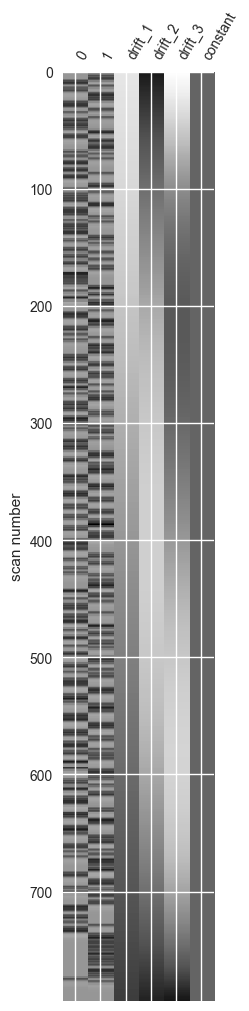

In [56]:
plot_design_matrix(design_matrix)


In [57]:
from stats import *


In [58]:
all_labels = pd.concat([ds.labels for ds in dataset], ignore_index=True)

cur_mean, cur_std = compute_morph_scores(all_labels)

_, fitted_curve = fit_sigmoid(cur_mean)


In [59]:
low_quartile = np.percentile(fitted_curve, 25)
low_inflexion = find_inflexion(fitted_curve, low_quartile)

high_quartile = np.percentile(fitted_curve, 75)
high_inflexion = find_inflexion(fitted_curve, high_quartile)

(low_inflexion, high_inflexion)

(np.float64(0.2743243243243243), np.float64(0.7247747747747747))

In [60]:
contrasts.keys()

dict_keys(['0', '1', 'drift_1', 'drift_2', 'drift_3', 'constant'])

In [61]:
glm_contrast_val = contrasts["1"] - contrasts["0"]
glm_contrast_val

array([-1.,  1.,  0.,  0.,  0.,  0.])

In [62]:
z_score = fmri_glm.compute_contrast(glm_contrast_val, stat_type='t')

In [63]:
z_score.get_fdata().max()

np.float64(6.645006517203939)

In [141]:
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map


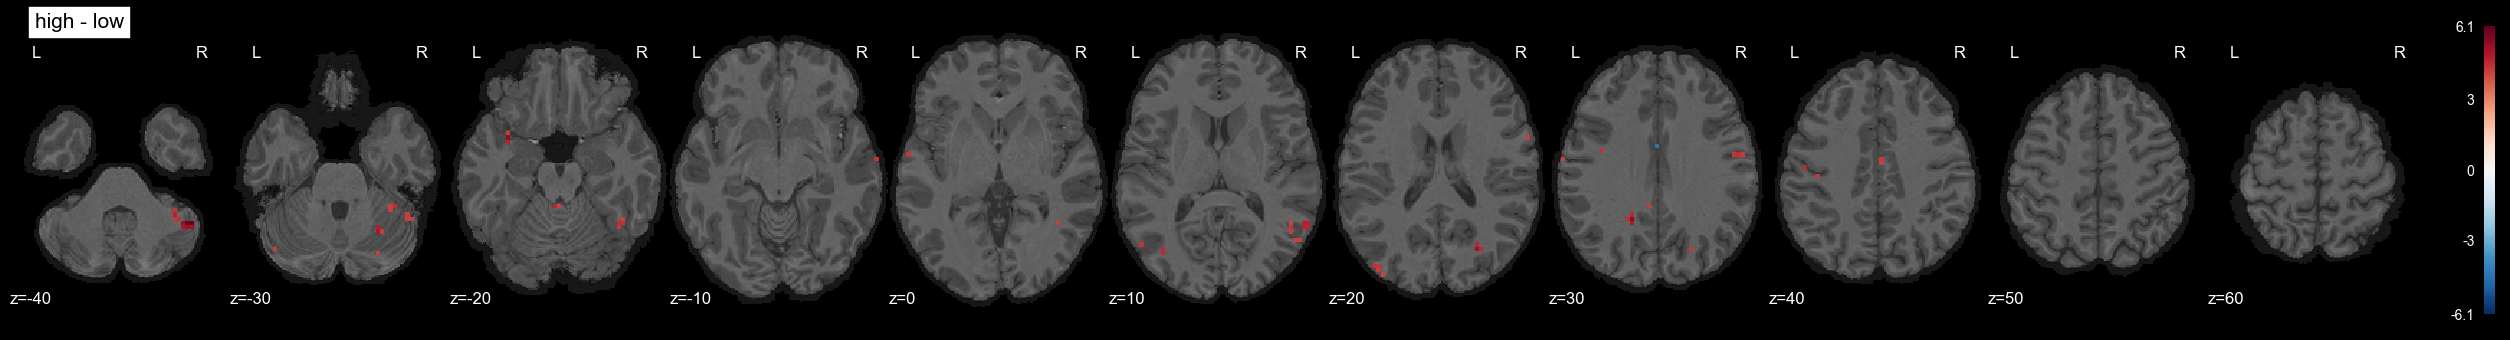

In [151]:
clean_z, threshold = threshold_stats_img(z_score, alpha=0.01, height_control="fdr")

plot_stat_map(
    clean_z,
    display_mode="z",
    title="high - low",
    cut_coords=np.arange(-40, 70, 10),
    bg_img=dataset[0].background,
    black_bg=True,
)

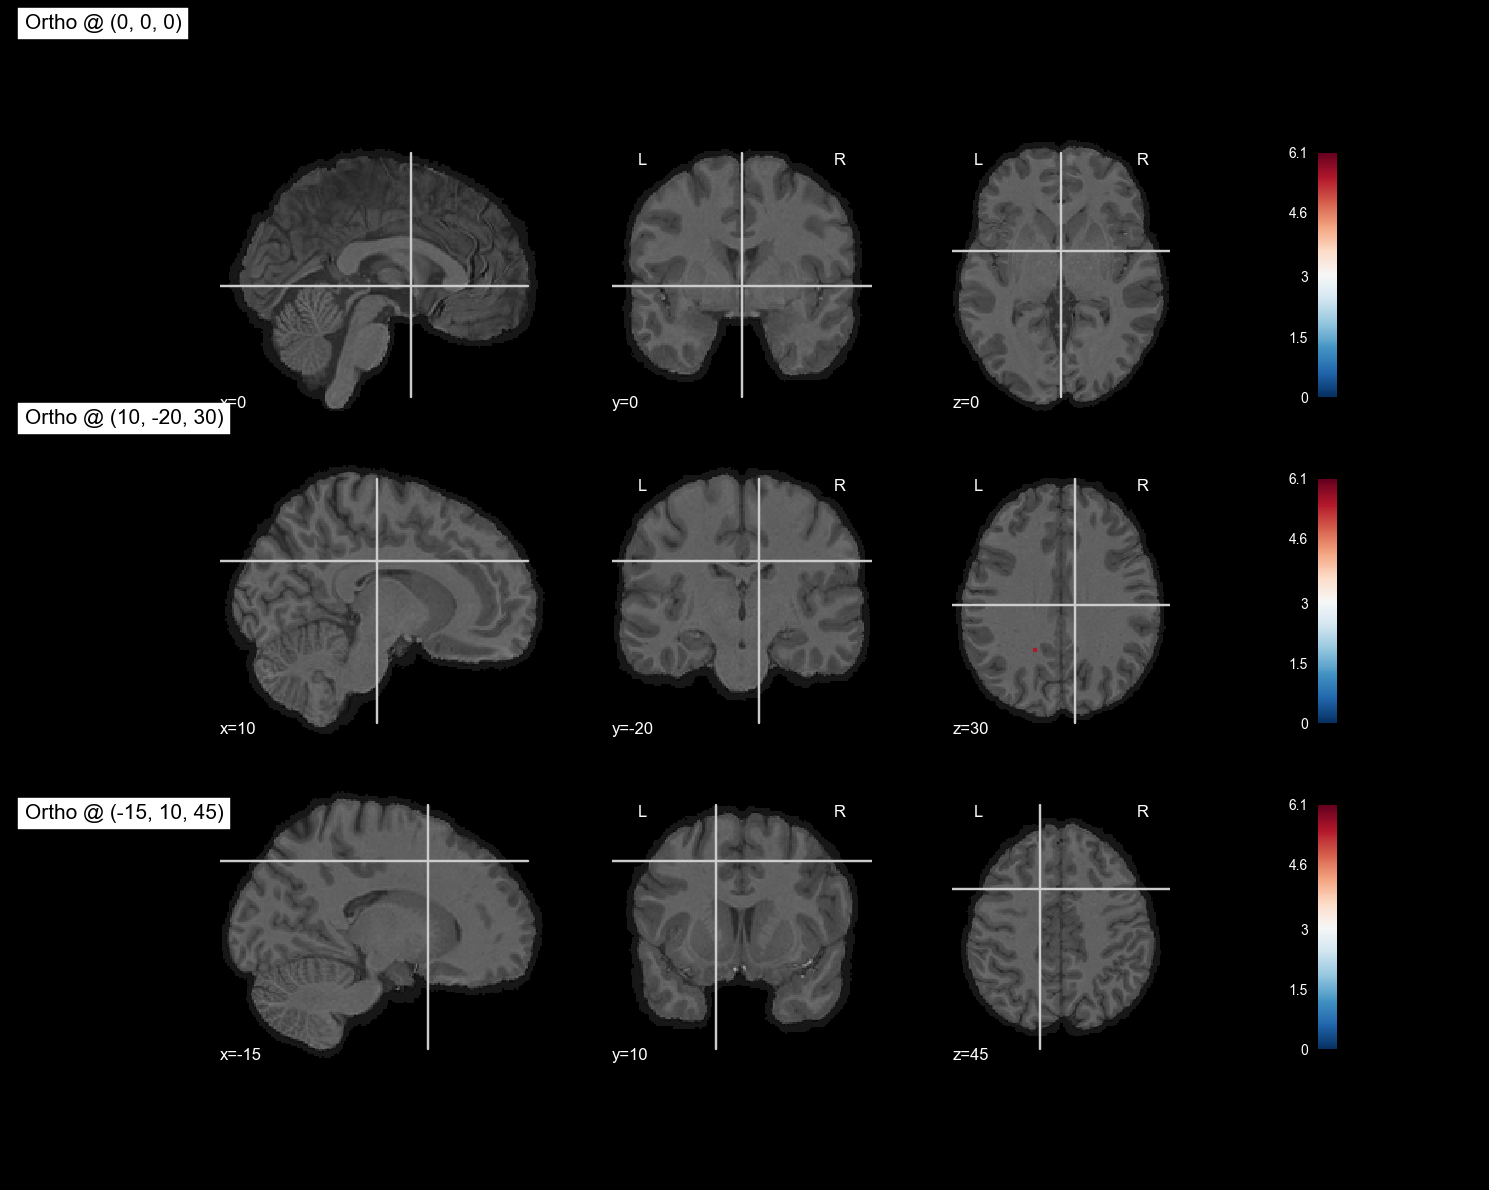

In [143]:
# Define multiple (x, y, z) ortho coordinates
cut_coords_list = [
    (0, 0, 0),
    (10, -20, 30),
    (-15, 10, 45),
]

n_coords = len(cut_coords_list)

plt.style.use('dark_background')
fig, axes = plt.subplots(
    n_coords, 1,
    figsize=(15, 4 * n_coords)
)

for ax, coords in zip(axes, cut_coords_list):
    plot_stat_map(
        clean_z,
        display_mode='ortho',
        cut_coords=coords,
        axes=ax,
        bg_img=dataset[0].background,
        title=f"Ortho @ {coords}",
        colorbar=True
    )

plt.tight_layout()
plt.show()

In [144]:
threshold

np.float64(4.925798208581741)

In [145]:
clean_z.get_fdata().max()

np.float64(6.0678286646922475)

In [146]:
plotting.view_img(clean_z)


NameError: name 'plotting' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = clean_z.get_fdata()
plt.hist(data.ravel(), bins=100)
plt.title("Histogram of Z-scores")
plt.show()

In [ ]:
from nilearn.masking import apply_mask
import matplotlib.pyplot as plt

mask = dataset[0].brain_mask

masked_data = apply_mask(clean_z, mask)
masked_data = masked_data[masked_data > 0.5]

plt.hist(masked_data, bins=50)
plt.title("Histogram of Z-scores (Brain Voxels Only)")
plt.xlabel("Z-score")
plt.show()

print(f"Min value: {masked_data.min()}")
print(f"Max value: {masked_data.max()}")


In [ ]:
len(masked_data)

In [ ]:
import numpy as np

contrast_val = np.array([ 1.,  1.,  0.,  0.,  1.,  0.,  0., -1., -1., -1.,  0.,  0.,  0., 0.])

contrast_val = np.squeeze(contrast_val)

print(contrast_val)

z_map = fmri_glm.compute_contrast(contrast_val, stat_type='t')

from nilearn.masking import apply_mask
#masked_data = apply_mask(z_map, dataset[0].brain_mask)

print(f"Min: {masked_data.min()}")
print(f"Max: {masked_data.max()}")


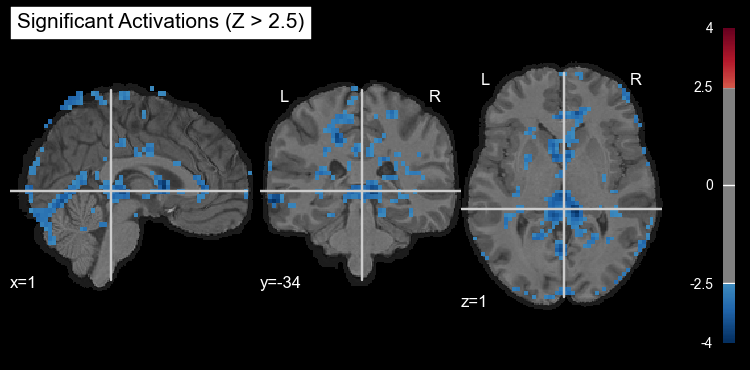

In [34]:
plot_stat_map(z_map,
              bg_img=dataset[0].background,
              threshold=2.5,
              title="Significant Activations (Z > 2.5)",
              colorbar=True)

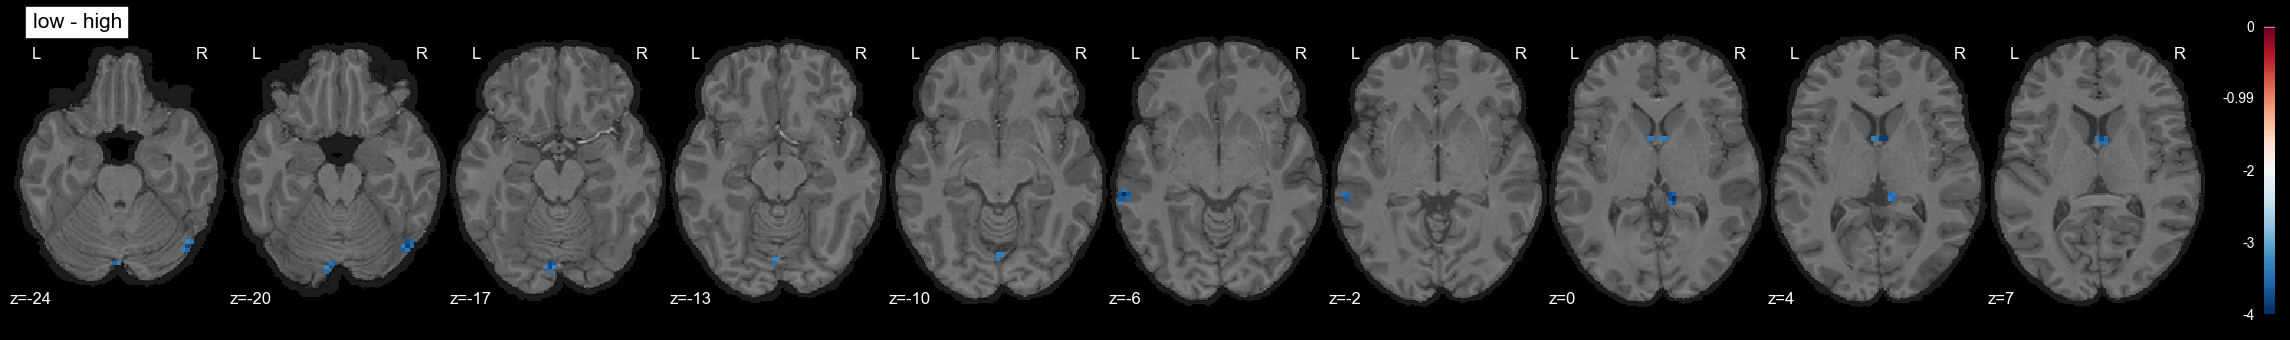

In [35]:
clean_z, threshold = threshold_stats_img(z_map, alpha=0.001, height_control="fpr", cluster_threshold=10)

plot_stat_map(
    clean_z,
    bg_img=dataset[0].background,
    display_mode="z",
    title="low - high",
    cut_coords=10,
    black_bg=True,
)

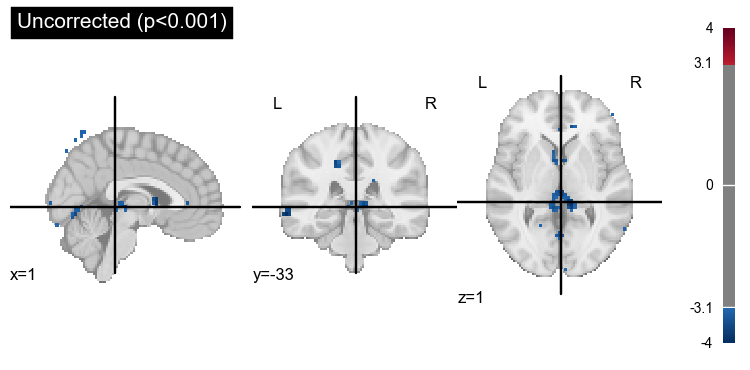

In [36]:
plot_stat_map(z_map,
              threshold=3.1,
              title="Uncorrected (p<0.001)")

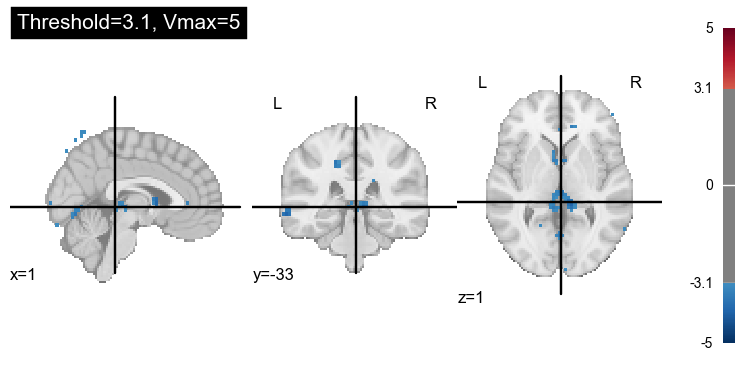

In [37]:
plot_stat_map(z_map,
              threshold=3.1,
              vmax=5.0,        # Force the color scale to go up to 5
              colorbar=True,
              title="Threshold=3.1, Vmax=5")


In [38]:
import numpy as np

# Get the data inside the brain
data = z_map.get_fdata()
masked_data = data[data != 0] # Ignore outside air

# Count how many voxels are significant
total_voxels = len(masked_data)
significant_voxels = np.sum(masked_data > 3.1)
percent_active = (significant_voxels / total_voxels) * 100

print(f"Total brain voxels: {total_voxels}")
print(f"Voxels above 3.1:   {significant_voxels}")
print(f"Percentage of brain active: {percent_active:.2f}%")


Total brain voxels: 58843
Voxels above 3.1:   0
Percentage of brain active: 0.00%


In [28]:
from nilearn.glm import threshold_stats_img

# Let nilearn calculate the threshold
thresholded_map, calculated_threshold = threshold_stats_img(
    z_map,
    alpha=0.5,
    height_control='fdr' # or 'bonferroni'
)

print(f"Manual Uncorrected Threshold: 3.1")
print(f"Calculated Corrected Threshold: {calculated_threshold}")


NameError: name 'z_map' is not defined

In [40]:
glm_contrast_val = contrasts["45"] + contrasts["55"] - contrasts["5"] - contrasts["15"]
z_score = fmri_glm.compute_contrast(glm_contrast_val, stat_type='t')

# m2 pierrard

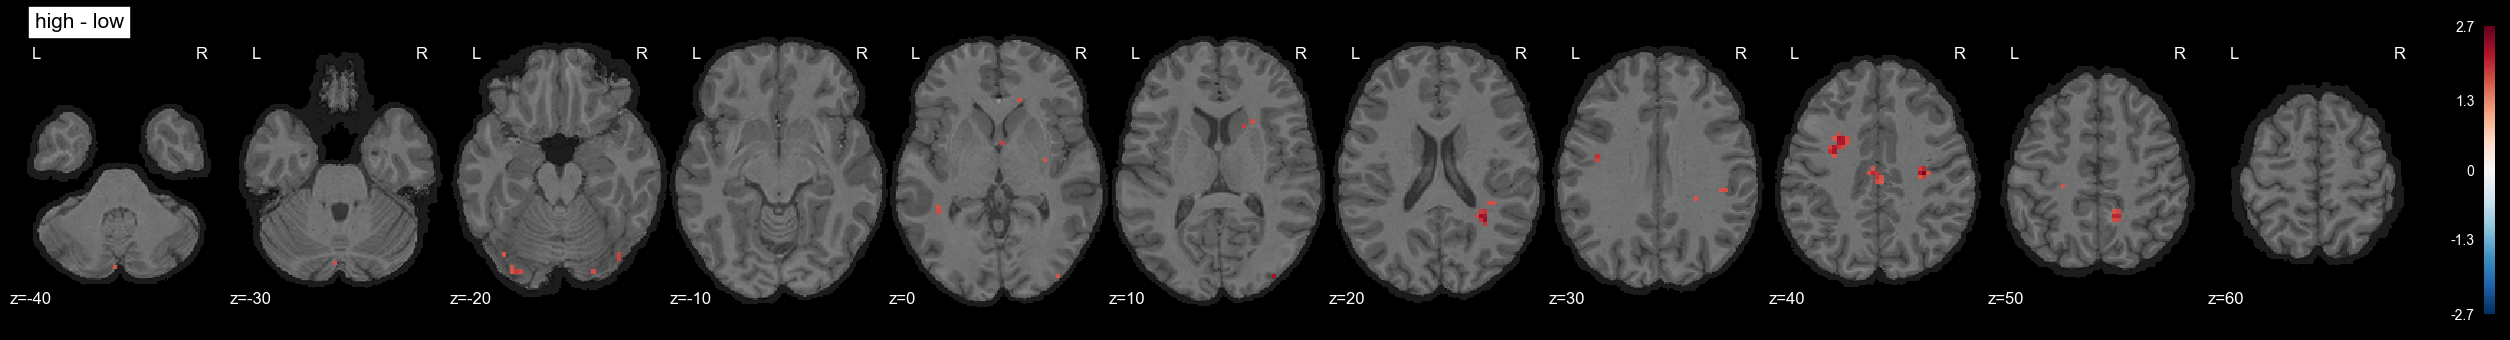

In [41]:
clean_z, threshold = threshold_stats_img(z_score, alpha=0.1, height_control="fpr")

plot_stat_map(
    clean_z,
    display_mode="z",
    title="high - low",
    cut_coords=np.arange(-40, 70, 10),
    bg_img=dataset[0].background,
    black_bg=True,
)

In [25]:
from nilearn.reporting import get_clusters_table
from brain_map import find_region_names

from nilearn import datasets


In [26]:
import lib.mni_to_atlas as mni_to_atlas

mni_to_atlas._ATLASES_PATH = "../lib"

atlas = mni_to_atlas.AtlasBrowser("AAL3")


In [67]:
atlas_name = 'cort-maxprob-thr0-1mm'
harvard = datasets.fetch_atlas_harvard_oxford(atlas_name=atlas_name)

atlas_img = harvard.maps
labels = harvard.labels

regions_activated = {}

glm_contrast_val = contrasts["1"] - contrasts["0"]

z_score = fmri_glm.compute_contrast(glm_contrast_val, stat_type='t')

clean, threshold = threshold_stats_img(z_score, alpha=0.05, height_control="bonferroni", cluster_threshold=5)
table = get_clusters_table(
    clean, stat_threshold=threshold, cluster_threshold=5
)

pos = [np.array((x,y,z)) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

regions_names = []

for p in pos:
    projected_coords = atlas.project_to_nearest(p)
    projected_regions = atlas.find_regions(projected_coords)

    regions_names.append(*projected_regions)

print(f"{regions_names=}")


[fetch_atlas_harvard_oxford] Dataset found in C:\Users\ducat\nilearn_data\fsl

regions_names=['Pallidum_L']
